In [ ]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    break

In [ ]:
!ls /kaggle/input

In [ ]:
import os

for dirname, dirs, files in os.walk('/kaggle/input'):
    print(dirname)

In [ ]:
!find /kaggle/input -name "stage_2_train_labels.csv"

In [5]:
import pandas as pd

base_path = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge"

labels = pd.read_csv(
    f"{base_path}/stage_2_train_labels.csv"
)

print("Shape :", labels.shape)
labels.head()

Shape : (30227, 6)


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


In [6]:
df = labels.groupby("patientId")["Target"].max().reset_index()

df["path"] = df["patientId"].apply(
    lambda x: f"{base_path}/stage_2_train_images/{x}.dcm"
)

print("Shape du dataframe :", df.shape)

df.head()

Shape du dataframe : (26684, 3)


,patientId,Target,path
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0,/kaggle/input/competitions/rsna-pneumonia-dete...
1,000924cf-0f8d-42bd-9158-1af53881a557,0,/kaggle/input/competitions/rsna-pneumonia-dete...
2,000db696-cf54-4385-b10b-6b16fbb3f985,1,/kaggle/input/competitions/rsna-pneumonia-dete...
3,000fe35a-2649-43d4-b027-e67796d412e0,1,/kaggle/input/competitions/rsna-pneumonia-dete...
4,001031d9-f904-4a23-b3e5-2c088acd19c6,1,/kaggle/input/competitions/rsna-pneumonia-dete...


In [ ]:
df.to_csv(
    "/kaggle/working/df_clean.csv",
    index=False
)

In [ ]:
!ls /kaggle/working

In [ ]:
print(df.shape)
df["Target"].value_counts()

In [7]:
# Imports
import os
import cv2
import pydicom
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A


# Chemin dataset Kaggle
base_path = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge"



def apply_clahe(image):
    """
    Applique CLAHE pour améliorer le contraste local.
    Entrée : image grayscale uint8
    Sortie : image RGB uint8
    """
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(gray)
    enhanced_rgb = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

    return enhanced_rgb


def read_dicom_image(path, image_size=224, use_clahe=True):
    """
    Lit une image DICOM RSNA et applique le prétraitement.
    """
    dcm = pydicom.dcmread(path)
    image = dcm.pixel_array.astype(np.float32)

    # Normalisation entre 0 et 255
    image = image - image.min()
    image = image / image.max()
    image = (image * 255).astype(np.uint8)

    # CLAHE ou simple conversion RGB
    if use_clahe:
        image = apply_clahe(image)
    else:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    # Redimensionnement
    image = cv2.resize(image, (image_size, image_size))

    return image


train_augmentation = A.Compose([
    A.Rotate(limit=10, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.RandomScale(scale_limit=0.10, p=0.4),
    A.Resize(224, 224),
])


In [ ]:
sample_path = df.iloc[0]["path"]

original = read_dicom_image(sample_path, use_clahe=False)
clahe_img = read_dicom_image(sample_path, use_clahe=True)

augmented = train_augmentation(image=clahe_img)["image"]

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Originale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(clahe_img)
plt.title("Avec CLAHE")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(augmented)
plt.title("CLAHE + Augmentation")
plt.axis("off")

plt.show()

In [8]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["Target"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["Target"],
    random_state=42
)

print("Train :", len(train_df))
print("Validation :", len(val_df))
print("Test :", len(test_df))

Train : 18678
Validation : 4003
Test : 4003


In [ ]:
print("\nTrain")
print(train_df["Target"].value_counts(normalize=True)*100)

print("\nValidation")
print(val_df["Target"].value_counts(normalize=True)*100)

print("\nTest")
print(test_df["Target"].value_counts(normalize=True)*100)

In [ ]:
train_df.to_csv("/kaggle/working/train_df.csv", index=False)
val_df.to_csv("/kaggle/working/val_df.csv", index=False)
test_df.to_csv("/kaggle/working/test_df.csv", index=False)

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class RSNADataset(Dataset):
    def __init__(self, dataframe, augmentation=None, use_clahe=True):
        self.dataframe = dataframe.reset_index(drop=True)
        self.augmentation = augmentation
        self.use_clahe = use_clahe

        self.normalize = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        path = self.dataframe.loc[idx, "path"]
        label = self.dataframe.loc[idx, "Target"]

        image = read_dicom_image(
            path,
            image_size=224,
            use_clahe=self.use_clahe
        )

        if self.augmentation:
            image = self.augmentation(image=image)["image"]

        image = self.normalize(image)
        label = torch.tensor(label, dtype=torch.long)

        return image, label

In [7]:
train_dataset = RSNADataset(train_df, augmentation=train_augmentation, use_clahe=True)
val_dataset = RSNADataset(val_df, augmentation=None, use_clahe=True)
test_dataset = RSNADataset(test_df, augmentation=None, use_clahe=True)

NameError: name 'train_augmentation' is not defined

In [10]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

NameError: name 'train_dataset' is not defined

In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(labels[:10])

In [ ]:
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

train_sample = train_df.groupby("Target", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 1500), random_state=42)
)

val_sample = val_df.groupby("Target", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 500), random_state=42)
)

print(train_sample["Target"].value_counts())
print(val_sample["Target"].value_counts())

def extract_hog_features(dataframe):
    features = []
    labels = []

    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        path = row["path"]
        label = row["Target"]

        image = read_dicom_image(path, image_size=224, use_clahe=True)

        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

        hog_feature = hog(
            gray,
            orientations=9,
            pixels_per_cell=(16, 16),
            cells_per_block=(2, 2),
            block_norm="L2-Hys",
            feature_vector=True
        )

        features.append(hog_feature)
        labels.append(label)

    return np.array(features), np.array(labels)


X_train_hog, y_train_hog = extract_hog_features(train_sample)
X_val_hog, y_val_hog = extract_hog_features(val_sample)

print(X_train_hog.shape)
print(y_train_hog.shape)
print(X_val_hog.shape)
print(y_val_hog.shape)

svm_model = LinearSVC(
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

svm_model.fit(X_train_hog, y_train_hog)

y_pred = svm_model.predict(X_val_hog)

print("Accuracy :", accuracy_score(y_val_hog, y_pred))
print("Precision :", precision_score(y_val_hog, y_pred))
print("Recall :", recall_score(y_val_hog, y_pred))
print("F1-score :", f1_score(y_val_hog, y_pred))

print("\nClassification report :")
print(classification_report(y_val_hog, y_pred, target_names=["Non pneumonie", "Pneumonie"]))

print("\nMatrice de confusion :")
print(confusion_matrix(y_val_hog, y_pred))

In [ ]:
baseline_results = {
    "model": "HOG + Linear SVM",
    "accuracy": accuracy_score(y_val_hog, y_pred),
    "precision": precision_score(y_val_hog, y_pred),
    "recall": recall_score(y_val_hog, y_pred),
    "f1_score": f1_score(y_val_hog, y_pred)
}

baseline_df = pd.DataFrame([baseline_results])
baseline_df.to_csv("/kaggle/working/baseline_hog_svm_results.csv", index=False)

baseline_df

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#print(device)

learning_rate = 1e-4
batch_size = 32
num_epochs = 20
weight_decay = 1e-4
dropout_rate = 0.3


model = models.resnet50(
    weights=models.ResNet50_Weights.IMAGENET1K_V2
)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Sequential(
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Dropout(dropout_rate),
    nn.Linear(512, 2)
)

model = model.to(device)

# print(model.fc)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df["Target"]),
    y=train_df["Target"]
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
).to(device)

print(class_weights)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

class EarlyStopping:

    def __init__(self, patience=5, min_delta=0):

        self.patience = patience
        self.min_delta = min_delta

        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):

        if self.best_loss is None:
            self.best_loss = val_loss

        elif val_loss > self.best_loss - self.min_delta:

            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True

        else:
            self.best_loss = val_loss
            self.counter = 0

early_stopping = EarlyStopping(patience=5)

In [ ]:
best_val_loss = float("inf")

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    # =====================
    # Entraînement
    # =====================
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # =====================
    # Validation
    # =====================
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)

    # =====================
    # Sauvegarde meilleur modèle
    # =====================
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "/kaggle/working/best_resnet50.pth"
        )

        print("Best model saved")

    # =====================
    # Historique des pertes
    # =====================
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

    # =====================
    # Early stopping
    # =====================
    early_stopping(val_loss)

    if early_stopping.early_stop:

        print("Early stopping")
        break

In [ ]:
model.load_state_dict(
    torch.load("/kaggle/working/best_resnet50.pth")
)

model.eval()

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Accuracy :", accuracy_score(all_labels, all_preds))
print("Precision :", precision_score(all_labels, all_preds))
print("Recall :", recall_score(all_labels, all_preds))
print("F1-score :", f1_score(all_labels, all_preds))

print(confusion_matrix(all_labels, all_preds))

In [ ]:
from sklearn.metrics import roc_auc_score

probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        prob = torch.softmax(outputs, dim=1)[:,1]

        probs.extend(prob.cpu().numpy())

auc = roc_auc_score(all_labels, probs)

print("AUC :", auc)

In [ ]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/notebooks/souhailmdaouer/notebook5a6b7fa447/baseline_hog_svm_results.csv
/kaggle/input/notebooks/souhailmdaouer/notebook5a6b7fa447/val_df.csv
/kaggle/input/notebooks/souhailmdaouer/notebook5a6b7fa447/best_resnet50.pth
/kaggle/input/notebooks/souhailmdaouer/notebook5a6b7fa447/__results__.html
/kaggle/input/notebooks/souhailmdaouer/notebook5a6b7fa447/__notebook__.ipynb
/kaggle/input/notebooks/souhailmdaouer/notebook5a6b7fa447/train_df.csv
/kaggle/input/notebooks/souhailmdaouer/notebook5a6b7fa447/__output__.json
/kaggle/input/notebooks/souhailmdaouer/notebook5a6b7fa447/df_clean.csv
/kaggle/input/notebooks/souhailmdaouer/notebook5a6b7fa447/test_df.csv
/kaggle/input/notebooks/souhailmdaouer/notebook5a6b7fa447/custom.css
/kaggle/input/notebooks/souhailmdaouer/notebook5a6b7fa447/__results___files/__results___10_0.png
/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_sample_submission.csv
/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_de

In [2]:
base_path = "/kaggle/input/notebooks/souhailmdaouer/notebook5a6b7fa447"

import pandas as pd

train_df = pd.read_csv(f"{base_path}/train_df.csv")
val_df = pd.read_csv(f"{base_path}/val_df.csv")
test_df = pd.read_csv(f"{base_path}/test_df.csv")
df = pd.read_csv(f"{base_path}/df_clean.csv")

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(18678, 3)
(4003, 3)
(4003, 3)


In [3]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Sequential(
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 2)
)

model = model.to(device)

model.load_state_dict(
    torch.load(
        f"{base_path}/best_resnet50.pth",
        map_location=device
    )
)

model.eval()

print("ResNet50 chargé avec succès")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 194MB/s] 


ResNet50 chargé avec succès


In [15]:
from torch.utils.data import DataLoader

test_dataset = RSNADataset(
    test_df,
    augmentation=None,
    use_clahe=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)
images, labels = next(iter(test_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import torch
import numpy as np

all_labels = []
all_preds = []
all_probs = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, all_preds)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1-score :", f1)
print("AUC :", auc)

print("\nMatrice de confusion :")
print(cm)

print("\nClassification report :")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["Non pneumonie", "Pneumonie"]
    )
)

Accuracy : 0.7381963527354484
Precision : 0.45431789737171463
Recall : 0.8048780487804879
F1-score : 0.5808
AUC : 0.8360156333233468

Matrice de confusion :
[[2229  872]
 [ 176  726]]

Classification report :
               precision    recall  f1-score   support

Non pneumonie       0.93      0.72      0.81      3101
    Pneumonie       0.45      0.80      0.58       902

     accuracy                           0.74      4003
    macro avg       0.69      0.76      0.70      4003
 weighted avg       0.82      0.74      0.76      4003



In [40]:
resnet50_results = {
    "model": "ResNet50 Transfer Learning",
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "auc": auc
}

resnet50_results_df = pd.DataFrame([resnet50_results])

resnet50_results_df.to_csv(
    "/kaggle/working/resnet50_results.csv",
    index=False
)

resnet50_results_df

,model,accuracy,precision,recall,f1_score,auc
0,ResNet50 Transfer Learning,0.801899,0.54735,0.698448,0.613736,0.865271


In [24]:
from torch.utils.data import DataLoader

train_dataset = RSNADataset(
    train_df,
    augmentation=train_augmentation,
    use_clahe=True
)

val_dataset = RSNADataset(
    val_df,
    augmentation=None,
    use_clahe=True
)

test_dataset = RSNADataset(
    test_df,
    augmentation=None,
    use_clahe=True
)

In [28]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(device)

learning_rate = 1e-4
num_epochs = 20
weight_decay = 1e-4
dropout_rate = 0.3


densenet = models.densenet121(
    weights=models.DenseNet121_Weights.IMAGENET1K_V1
)

for param in densenet.parameters():
    param.requires_grad = False

num_features = densenet.classifier.in_features

densenet.classifier = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(dropout_rate),
    nn.Linear(512, 2)
)

# Fine tuning
for param in densenet.features.denseblock4.parameters():
    param.requires_grad = True

for param in densenet.features.norm5.parameters():
    param.requires_grad = True

densenet = densenet.to(device)

#print(densenet.classifier)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["Target"]),
    y=train_df["Target"]
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad,
           densenet.parameters()),
    lr=learning_rate,
    weight_decay=weight_decay
)


class EarlyStopping:

    def __init__(self, patience=5, min_delta=0.001):

        self.patience = patience
        self.min_delta = min_delta

        self.counter = 0
        self.best_loss = None

        self.early_stop = False

    def __call__(self, val_loss):

        if self.best_loss is None:
            self.best_loss = val_loss

        elif val_loss > self.best_loss - self.min_delta:

            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True

        else:

            self.best_loss = val_loss
            self.counter = 0


early_stopping = EarlyStopping(
    patience=5,
    min_delta=0.001
)

In [36]:
best_val_loss = float("inf")

train_losses_densenet = []
val_losses_densenet = []

for epoch in range(num_epochs):

    densenet.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = densenet(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    densenet.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = densenet(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)

    if val_loss < best_val_loss:
        best_val_loss = val_loss

        torch.save(
            densenet.state_dict(),
            "/kaggle/working/best_densenet121.pth"
        )

        print("Best DenseNet121 model saved")

    train_losses_densenet.append(train_loss)
    val_losses_densenet.append(val_loss)

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

    early_stopping(val_loss)

    if early_stopping.early_stop:
        print("Early stopping")
        break

100%|██████████| 584/584 [03:54<00:00,  2.49it/s]


Best DenseNet121 model saved
Epoch 1/20 Train Loss: 0.5154 Val Loss: 0.4738


100%|██████████| 584/584 [03:13<00:00,  3.02it/s]


Best DenseNet121 model saved
Epoch 2/20 Train Loss: 0.4683 Val Loss: 0.4678


100%|██████████| 584/584 [03:13<00:00,  3.02it/s]


...

Epoch 5/20 Train Loss: 0.4122 Val Loss: 0.4756


100%|██████████| 584/584 [03:11<00:00,  3.04it/s]


Epoch 6/20 Train Loss: 0.3816 Val Loss: 0.5216


100%|██████████| 584/584 [03:11<00:00,  3.06it/s]


Epoch 7/20 Train Loss: 0.3648 Val Loss: 0.5118
Early stopping


In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import torch
import numpy as np

all_labels = []
all_preds = []
all_probs = []


densenet.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = densenet(images)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, all_preds)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1-score :", f1)
print("AUC :", auc)

print("\nMatrice de confusion :")
print(cm)

print("\nClassification report :")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["Non pneumonie", "Pneumonie"]
    )
)

Accuracy : 0.801898576067949
Precision : 0.5473501303214596
Recall : 0.6984478935698448
F1-score : 0.6137359961032636
AUC : 0.8652712700502162

Matrice de confusion :
[[2580  521]
 [ 272  630]]

Classification report :
               precision    recall  f1-score   support

Non pneumonie       0.90      0.83      0.87      3101
    Pneumonie       0.55      0.70      0.61       902

     accuracy                           0.80      4003
    macro avg       0.73      0.77      0.74      4003
 weighted avg       0.82      0.80      0.81      4003



In [41]:
densenet_results = {
    "model": "DenseNet121 Transfer Learning",
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "auc": auc
}

densenet_results_df = pd.DataFrame([densenet_results])

densenet_results_df.to_csv(
    "/kaggle/working/densenet121_results.csv",
    index=False
)

densenet_results_df

,model,accuracy,precision,recall,f1_score,auc
0,DenseNet121 Transfer Learning,0.801899,0.54735,0.698448,0.613736,0.865271


In [46]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    if len(filenames) > 0:
        print(dirname)
        print(filenames[:5])

/kaggle/input/notebooks/souhailmdaouer/notebook5a6b7fa447
['baseline_hog_svm_results.csv', 'val_df.csv', 'best_resnet50.pth', '__results__.html', '__notebook__.ipynb']
/kaggle/input/notebooks/souhailmdaouer/notebook5a6b7fa447/__results___files
['__results___10_0.png']
/kaggle/input/notebooks/nikhilpandey360/lung-segmentation-from-chest-x-ray-dataset
['__results__.html', 'cxr_reg_weights.best.hdf5', '__output__.json', 'custom.css']
/kaggle/input/notebooks/nikhilpandey360/lung-segmentation-from-chest-x-ray-dataset/__results___files
['__results___10_5.png', '__results___24_0.png', '__results___10_4.png', '__results___10_1.png', '__results___10_2.png']
/kaggle/input/competitions/rsna-pneumonia-detection-challenge
['stage_2_sample_submission.csv', 'stage_2_detailed_class_info.csv', 'GCP Credits Request Link - RSNA.txt', 'stage_2_train_labels.csv']
/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images
['c3b05294-29be-46e4-8a51-96fd211e4ca5.dcm', '6a6ed2c5-d179-4c

In [10]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate
from tensorflow.keras.models import Model

def build_unet(input_size=(256, 256, 1)):
    inputs = Input(input_size)

    c1 = Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(128, 3, activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(256, 3, activation='relu', padding='same')(p3)
    c4 = Conv2D(256, 3, activation='relu', padding='same')(c4)
    p4 = MaxPooling2D((2, 2))(c4)

    c5 = Conv2D(512, 3, activation='relu', padding='same')(p4)
    c5 = Conv2D(512, 3, activation='relu', padding='same')(c5)

    u6 = Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(256, 3, activation='relu', padding='same')(u6)
    c6 = Conv2D(256, 3, activation='relu', padding='same')(c6)

    u7 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(128, 3, activation='relu', padding='same')(u7)
    c7 = Conv2D(128, 3, activation='relu', padding='same')(c7)

    u8 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(64, 3, activation='relu', padding='same')(u8)
    c8 = Conv2D(64, 3, activation='relu', padding='same')(c8)

    u9 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv2D(32, 3, activation='relu', padding='same')(u9)
    c9 = Conv2D(32, 3, activation='relu', padding='same')(c9)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model

unet_path = "/kaggle/input/notebooks/nikhilpandey360/lung-segmentation-from-chest-x-ray-dataset/cxr_reg_weights.best.hdf5"

unet_model = build_unet(input_size=(256, 256, 1))
unet_model.load_weights(unet_path)

print("Poids U-Net chargés avec succès")

2026-07-04 01:46:02.216808: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783129562.447303      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783129562.520774      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783129563.069392      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783129563.069442      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783129563.069446      58 computation_placer.cc:177] computation placer alr

Poids U-Net chargés avec succès


I0000 00:00:1782364609.379805     671 service.cc:152] XLA service 0x7dba68006f80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782364609.379869     671 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782364609.379875     671 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782364609.625189     671 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-25 05:16:52.003823: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-25 05:16:52.202215: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1782364613.275217     671 device_co

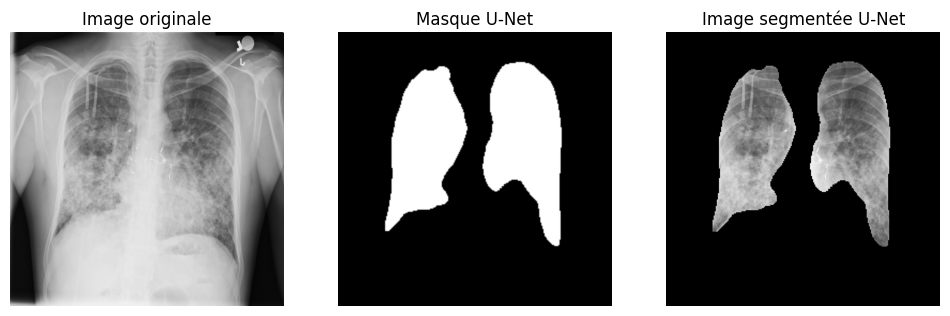

In [54]:
import cv2
import pydicom
import numpy as np
import matplotlib.pyplot as plt

def read_dicom_gray(path):
    dcm = pydicom.dcmread(path)
    image = dcm.pixel_array.astype(np.float32)

    image = image - image.min()
    image = image / image.max()
    image = (image * 255).astype(np.uint8)

    return image


def segment_lungs_unet_keras(image, model, input_size=256, threshold=0.5):
    h, w = image.shape

    img = cv2.resize(image, (input_size, input_size))
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=-1)
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img, verbose=0)[0, :, :, 0]

    mask = (pred > threshold).astype(np.uint8) * 255
    mask = cv2.resize(mask, (w, h))

    segmented = cv2.bitwise_and(image, image, mask=mask)

    return segmented, mask


sample_path = train_df.iloc[0]["path"]

img = read_dicom_gray(sample_path)
segmented, mask = segment_lungs_unet_keras(img, unet_model)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Image originale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Masque U-Net")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(segmented, cmap="gray")
plt.title("Image segmentée U-Net")
plt.axis("off")

plt.show()

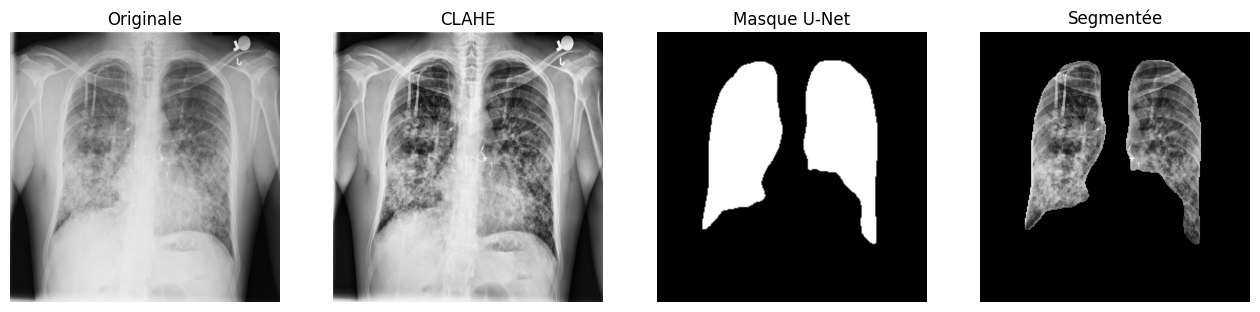

In [11]:
import cv2
import pydicom
import numpy as np
import matplotlib.pyplot as plt

def read_dicom_gray(path):
    dcm = pydicom.dcmread(path)
    image = dcm.pixel_array.astype(np.float32)

    image = image - image.min()
    image = image / image.max()
    image = (image * 255).astype(np.uint8)

    return image

def apply_clahe_gray(image):

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    image_clahe = clahe.apply(image)

    return image_clahe

def segment_lungs_unet_keras(image, model, input_size=256, threshold=0.5):
    h, w = image.shape

    img = cv2.resize(image, (input_size, input_size))
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=-1)
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img, verbose=0)[0, :, :, 0]

    mask = (pred > threshold).astype(np.uint8) * 255
    mask = cv2.resize(mask, (w, h))

    segmented = cv2.bitwise_and(image, image, mask=mask)

    return segmented, mask


sample_path = train_df.iloc[0]["path"]

img = read_dicom_gray(sample_path)

img_clahe = apply_clahe_gray(img)

segmented, mask = segment_lungs_unet_keras(
    img_clahe,
    unet_model
)

plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(img, cmap="gray")
plt.title("Originale")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(img_clahe, cmap="gray")
plt.title("CLAHE")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(mask, cmap="gray")
plt.title("Masque U-Net")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(segmented, cmap="gray")
plt.title("Segmentée")
plt.axis("off")

plt.show()


In [5]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

def read_dicom_image_segmented(path, image_size=224):
    image = read_dicom_gray(path)

    # CLAHE avant segmentation
    image_clahe = apply_clahe_gray(image)

    # Segmentation U-Net
    segmented, mask = segment_lungs_unet_keras(
        image_clahe,
        unet_model,
        input_size=256,
        threshold=0.5
    )

    # Resize + RGB
    segmented = cv2.resize(segmented, (image_size, image_size))
    segmented = cv2.cvtColor(segmented, cv2.COLOR_GRAY2RGB)

    return segmented
    

class RSNASegmentedDataset(Dataset):
    def __init__(self, dataframe, augmentation=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.augmentation = augmentation

        self.normalize = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        path = self.dataframe.loc[idx, "path"]
        label = self.dataframe.loc[idx, "Target"]

        image = read_dicom_image_segmented(path)

        if self.augmentation:
            image = self.augmentation(image=image)["image"]

        image = self.normalize(image)
        label = torch.tensor(label, dtype=torch.long)

        return image, label


train_seg_dataset = RSNASegmentedDataset(
    train_df,
    augmentation=train_augmentation
)

val_seg_dataset = RSNASegmentedDataset(
    val_df,
    augmentation=None
)

test_seg_dataset = RSNASegmentedDataset(
    test_df,
    augmentation=None
)

train_seg_loader = DataLoader(
    train_seg_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_seg_loader = DataLoader(
    val_seg_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

test_seg_loader = DataLoader(
    test_seg_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#print(device)

learning_rate = 1e-4
num_epochs = 20
weight_decay = 1e-4
dropout_rate = 0.3

densenet_seg = models.densenet121(
    weights=models.DenseNet121_Weights.IMAGENET1K_V1
)

for param in densenet_seg.parameters():
    param.requires_grad = False

num_features = densenet_seg.classifier.in_features

densenet_seg.classifier = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(dropout_rate),
    nn.Linear(512, 2)
)

for param in densenet_seg.features.denseblock4.parameters():
    param.requires_grad = True

for param in densenet_seg.features.norm5.parameters():
    param.requires_grad = True

densenet_seg = densenet_seg.to(device)

#print(densenet_seg.classifier)



class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["Target"]),
    y=train_df["Target"]
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
).to(device)

#print(class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, densenet_seg.parameters()),
    lr=learning_rate,
    weight_decay=weight_decay
)

class EarlyStopping:

    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):

        if self.best_loss is None:
            self.best_loss = val_loss

        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True

        else:
            self.best_loss = val_loss
            self.counter = 0


early_stopping = EarlyStopping(
    patience=3,
    min_delta=0.001
)

In [22]:
from tqdm import tqdm

best_val_loss = float("inf")

train_losses_seg = []
val_losses_seg = []

for epoch in range(num_epochs):

    densenet_seg.train()
    running_loss = 0.0

    for images, labels in tqdm(train_seg_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = densenet_seg(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_seg_loader)

    densenet_seg.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for images, labels in val_seg_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = densenet_seg(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_seg_loader)

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            densenet_seg.state_dict(),
            "/kaggle/working/best_densenet121_segmented.pth"
        )

        print("Best DenseNet121 segmented model saved")

    train_losses_seg.append(train_loss)
    val_losses_seg.append(val_loss)

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

    early_stopping(val_loss)

    if early_stopping.early_stop:
        print("Early stopping")
        break

100%|██████████| 584/584 [44:04<00:00,  4.53s/it]


Best DenseNet121 segmented model saved
Epoch 1/20 Train Loss: 0.5322 Val Loss: 0.4992


100%|██████████| 584/584 [43:43<00:00,  4.49s/it]


Best DenseNet121 segmented model saved
Epoch 2/20 Train Loss: 0.5023 Val Loss: 0.4859


100%|██████████| 584/584 [44:46<00:00,  4.60s/it]


Best DenseNet121 segmented model saved
Epoch 3/20 Train Loss: 0.4874 Val Loss: 0.4793


100%|██████████| 584/584 [44:28<00:00,  4.57s/it]


Best DenseNet121 segmented model saved
Epoch 4/20 Train Loss: 0.4740 Val Loss: 0.4793


100%|██████████| 584/584 [41:39<00:00,  4.28s/it]


Best DenseNet121 segmented model saved
Epoch 5/20 Train Loss: 0.4651 Val Loss: 0.4787
Early stopping


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import torch
import numpy as np

all_labels = []
all_preds = []
all_probs = []

densenet_seg.load_state_dict(
    torch.load("/kaggle/working/best_densenet121_segmented.pth", map_location=device)
)

densenet_seg.eval()

with torch.no_grad():

    for images, labels in test_seg_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = densenet_seg(images)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, all_preds)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1-score :", f1)
print("AUC :", auc)

print("\nMatrice de confusion :")
print(cm)

print("\nClassification report :")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["Non pneumonie", "Pneumonie"]
    )
)

Accuracy : 0.7289532850362228
Precision : 0.4455681142177275
Recall : 0.8303769401330376
F1-score : 0.5799457994579946
AUC : 0.8473790015523209

Matrice de confusion :
[[2169  932]
 [ 153  749]]

Classification report :
               precision    recall  f1-score   support

Non pneumonie       0.93      0.70      0.80      3101
    Pneumonie       0.45      0.83      0.58       902

     accuracy                           0.73      4003
    macro avg       0.69      0.76      0.69      4003
 weighted avg       0.82      0.73      0.75      4003



In [3]:
import os
import cv2
import pydicom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

base_path = "/kaggle/input/notebooks/souhailmdaouer/notebook5a6b7fa447"

train_df = pd.read_csv(f"{base_path}/train_df.csv")
val_df = pd.read_csv(f"{base_path}/val_df.csv")
test_df = pd.read_csv(f"{base_path}/test_df.csv")

print(train_df.shape, val_df.shape, test_df.shape)

(18678, 3) (4003, 3) (4003, 3)


In [4]:
import os
import cv2
import pydicom
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm

import albumentations as A



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

base_path = "/kaggle/input/notebooks/souhailmdaouer/notebook5a6b7fa447"

train_df = pd.read_csv(f"{base_path}/train_df.csv")
val_df = pd.read_csv(f"{base_path}/val_df.csv")
test_df = pd.read_csv(f"{base_path}/test_df.csv")

print(train_df.shape, val_df.shape, test_df.shape)

def apply_clahe_gray(image):
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )
    return clahe.apply(image)


def read_dicom_image(path, image_size=224, use_clahe=True):
    dcm = pydicom.dcmread(path)
    image = dcm.pixel_array.astype(np.float32)

    image = image - image.min()
    image = image / image.max()
    image = (image * 255).astype(np.uint8)

    if use_clahe:
        image = apply_clahe_gray(image)

    image = cv2.resize(image, (image_size, image_size))
    image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    return image


train_augmentation = A.Compose([
    A.Rotate(limit=10, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.RandomScale(scale_limit=0.10, p=0.4),
    A.Resize(224, 224),
])

cuda
(18678, 3) (4003, 3) (4003, 3)


In [5]:
from torch.utils.data import Dataset, DataLoader

class RSNADataset(Dataset):
    def __init__(self, dataframe, augmentation=None, use_clahe=True):
        self.dataframe = dataframe.reset_index(drop=True)
        self.augmentation = augmentation
        self.use_clahe = use_clahe

        self.normalize = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        path = self.dataframe.loc[idx, "path"]
        label = self.dataframe.loc[idx, "Target"]

        image = read_dicom_image(
            path,
            image_size=224,
            use_clahe=self.use_clahe
        )

        if self.augmentation:
            image = self.augmentation(image=image)["image"]

        image = self.normalize(image)
        label = torch.tensor(label, dtype=torch.float32)
       # label = torch.tensor(label, dtype=torch.long)

        return image, label

batch_size = 32

train_dataset = RSNADataset(train_df, augmentation=train_augmentation, use_clahe=True)
val_dataset = RSNADataset(val_df, augmentation=None, use_clahe=True)
test_dataset = RSNADataset(test_df, augmentation=None, use_clahe=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(len(train_loader), len(val_loader), len(test_loader))

584 126 126


In [3]:
!pip install optuna -q

In [2]:
import optuna
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score

class RSNADataset(Dataset):
    def __init__(self, dataframe, augmentation=None, use_clahe=True):
        self.dataframe = dataframe.reset_index(drop=True)
        self.augmentation = augmentation
        self.use_clahe = use_clahe

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = read_dicom_image(
            row["path"],
            image_size=224,
            use_clahe=self.use_clahe
        )

        label = int(row["Target"])   # correction ici

        if self.augmentation:
            augmented = self.augmentation(image=image)
            image = augmented["image"]

        image = image.astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))

        image = torch.tensor(image, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.float32)

        return image, label

val_dataset = RSNADataset(
    val_df,
    augmentation=A.Compose([A.Resize(224, 224)]),
    use_clahe=True
)

test_dataset = RSNADataset(
    test_df,
    augmentation=A.Compose([A.Resize(224, 224)]),
    use_clahe=True
)
def create_densenet121(trial):
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

    unfreeze_layers = trial.suggest_categorical(
        "unfreeze_layers",
        [0, 20, 50, 100]
    )

    for param in model.features.parameters():
        param.requires_grad = False

    if unfreeze_layers > 0:
        for param in list(model.features.parameters())[-unfreeze_layers:]:
            param.requires_grad = True

    dropout = trial.suggest_float("dropout", 0.2, 0.6)
    dense_units = trial.suggest_categorical("dense_units", [128, 256, 512])

    in_features = model.classifier.in_features

    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, dense_units),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(dense_units, 1)
    )

    return model.to(device)


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)

            running_loss += loss.item()

            all_labels.extend(labels.cpu().numpy().ravel())
            all_probs.extend(probs.cpu().numpy().ravel())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_preds = (all_probs >= 0.5).astype(int)

    val_loss = running_loss / len(loader)
    val_auc = roc_auc_score(all_labels, all_probs)
    val_recall = recall_score(all_labels, all_preds)
    val_precision = precision_score(all_labels, all_preds, zero_division=0)
    val_f1 = f1_score(all_labels, all_preds)

    return val_loss, val_auc, val_recall, val_precision, val_f1

def objective(trial):

    batch_size = trial.suggest_categorical(
        "batch_size",
        [16, 32]
    )

    train_dataset = RSNADataset(
        train_df,
        augmentation=train_augmentation,
        use_clahe=True
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    model = create_densenet121(trial)

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-5,
        1e-3,
        log=True
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-3,
        log=True
    )

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["Adam", "AdamW"]
    )

    if optimizer_name == "Adam":
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=learning_rate,
            weight_decay=weight_decay
        )
    else:
        optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    positive_class_weight = trial.suggest_float(
        "positive_class_weight",
        1.0,
        6.0
    )

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([positive_class_weight], device=device)
    )

    best_auc = 0.0
    patience = 3
    counter = 0

    for epoch in range(6):
        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_loss, val_auc, val_recall, val_precision, val_f1 = evaluate(
            model,
            val_loader,
            criterion
        )

        trial.report(val_auc, epoch)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        if val_auc > best_auc:
            best_auc = val_auc
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            break

    return best_auc

In [3]:
study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=20
)

print("Meilleurs paramètres :")
print(study.best_params)

print("Meilleur AUC validation :")
print(study.best_value)

[I 2026-06-28 16:49:39,158] A new study created in memory with name: no-name-0641f484-5d6b-40e7-86d5-c3378c6e5821


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 166MB/s] 
[I 2026-06-28 17:13:50,253] Trial 0 finished with value: 0.8635280372328217 and parameters: {'batch_size': 32, 'unfreeze_layers': 20, 'dropout': 0.27782525031151867, 'dense_units': 128, 'learning_rate': 0.0002840140729275262, 'weight_decay': 0.0003060169641387422, 'optimizer': 'Adam', 'positive_class_weight': 2.4696667511767063}. Best is trial 0 with value: 0.8635280372328217.
[I 2026-06-28 17:35:46,712] Trial 1 finished with value: 0.8187817247994531 and parameters: {'batch_size': 16, 'unfreeze_layers': 0, 'dropout': 0.3936241474093131, 'dense_units': 256, 'learning_rate': 6.590719796866539e-05, 'weight_decay': 5.366463461190918e-06, 'optimizer': 'Adam', 'positive_class_weight': 1.082068683907922}. Best is trial 0 with value: 0.8635280372328217.
[I 2026-06-28 17:57:47,740] Trial 2 finished with value: 0.8667919510979578 and parameters: {'batch_size': 16, 'unfreeze_layers': 20, 'dropout': 0.413703863777653, 'dense_units': 128, 'learn

Meilleurs paramètres :
{'batch_size': 32, 'unfreeze_layers': 100, 'dropout': 0.3350745495831822, 'dense_units': 512, 'learning_rate': 0.0006545776317255478, 'weight_decay': 1.7703130607090214e-06, 'optimizer': 'AdamW', 'positive_class_weight': 2.6448777190609833}
Meilleur AUC validation :
0.8743967863881975


In [8]:
batch_size = 32
learning_rate = 0.0006545776317255478
dropout_rate = 0.3350745495831822
dense_units = 512
weight_decay = 1.7703130607090214e-06
positive_class_weight = 2.6448777190609833
num_epochs = 20

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(
        [positive_class_weight],
        device=device
    )
)

from torchvision import models
import torch.nn as nn

densenet_optuna = models.densenet121(
    weights=models.DenseNet121_Weights.IMAGENET1K_V1
)

# Geler toutes les couches
for param in densenet_optuna.parameters():
    param.requires_grad = False

# Dégeler les 100 dernières couches
for param in densenet_optuna.features.parameters():
    param.requires_grad = False

for param in list(densenet_optuna.features.parameters())[-100:]:
    param.requires_grad = True

num_features = densenet_optuna.classifier.in_features

densenet_optuna.classifier = nn.Sequential(
    nn.Dropout(dropout_rate),
    nn.Linear(num_features, dense_units),
    nn.ReLU(),
    nn.Dropout(dropout_rate),
    nn.Linear(dense_units, 1)
)

densenet_optuna = densenet_optuna.to(device)

import torch.optim as optim

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, densenet_optuna.parameters()),
    lr=learning_rate,
    weight_decay=weight_decay
)

early_stopping = EarlyStopping(
    patience=5,
    min_delta=0.001
)


best_val_loss = float("inf")

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    densenet_optuna.train()

    running_loss = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = densenet_optuna(images)

        loss = criterion(outputs, labels.float())

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    densenet_optuna.eval()

    running_val_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)
            outputs = densenet_optuna(images)

            loss = criterion(outputs, labels.float())

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"Train Loss={train_loss:.4f} "
        f"Val Loss={val_loss:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            densenet_optuna.state_dict(),
            "/kaggle/working/best_densenet121_optunaV3.pth"
        )

        print("Best model saved.")

    early_stopping(val_loss)

    if early_stopping.early_stop:

        print("Early stopping")

        break

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 148MB/s] 
100%|██████████| 584/584 [04:42<00:00,  2.07it/s]


Epoch 1/20 Train Loss=0.6760 Val Loss=0.6195
Best model saved.


100%|██████████| 584/584 [03:40<00:00,  2.65it/s]


Epoch 2/20 Train Loss=0.6299 Val Loss=0.6167
Best model saved.


...

Epoch 8/20 Train Loss=0.5330 Val Loss=0.6908


100%|██████████| 584/584 [03:51<00:00,  2.52it/s]


Epoch 9/20 Train Loss=0.5209 Val Loss=0.6681


100%|██████████| 584/584 [03:39<00:00,  2.66it/s]


Epoch 10/20 Train Loss=0.4997 Val Loss=0.7958
Early stopping


In [9]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

all_labels = []
all_preds = []
all_probs = []



densenet_optuna.load_state_dict(
    torch.load(
        "/kaggle/working/best_densenet121_optunaV3.pth",
        map_location=device
    )
)

densenet_optuna.eval()

 
with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        outputs = densenet_optuna(images)
        probs = torch.sigmoid(outputs)

        preds = (probs >= 0.5).float()

        all_labels.extend(labels.cpu().numpy().ravel())
        all_preds.extend(preds.cpu().numpy().ravel())
        all_probs.extend(probs.cpu().numpy().ravel())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds,
    zero_division=0)
recall = recall_score(all_labels, all_preds,
    zero_division=0)
f1 = f1_score(all_labels, all_preds,
    zero_division=0)
auc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, all_preds)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1-score :", f1)
print("AUC :", auc)

print("\nMatrice de confusion :")
print(cm)

print("\nClassification report :")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["Non pneumonie", "Pneumonie"]
    )
)

Accuracy : 0.7854109417936548
Precision : 0.5156136528685549
Recall : 0.7871396895787139
F1-score : 0.6230802983764809
AUC : 0.8799410961774007

Matrice de confusion :
[[2434  667]
 [ 192  710]]

Classification report :
               precision    recall  f1-score   support

Non pneumonie       0.93      0.78      0.85      3101
    Pneumonie       0.52      0.79      0.62       902

     accuracy                           0.79      4003
    macro avg       0.72      0.79      0.74      4003
 weighted avg       0.83      0.79      0.80      4003



In [7]:
class EarlyStopping:

    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):

        if self.best_loss is None:
            self.best_loss = val_loss

        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True

        else:
            self.best_loss = val_loss
            self.counter = 0


early_stopping = EarlyStopping(
    patience=3,
    min_delta=0.001
)

class
No Lung Opacity / Not Normal    11821
Lung Opacity                     9555
Normal                           8851
Name: count, dtype: int64


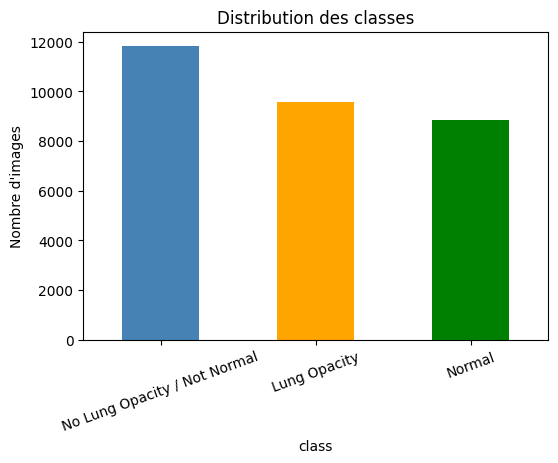

class
No Lung Opacity / Not Normal    39.11
Lung Opacity                    31.61
Normal                          29.28
Name: count, dtype: float64

In [17]:
import os
import cv2
import pydicom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

train_labels = pd.read_csv("/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_labels.csv")
class_info = pd.read_csv("/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_detailed_class_info.csv")

class_counts = class_info["class"].value_counts()

print(class_counts)

plt.figure(figsize=(6,4))

class_counts.plot(
    kind='bar',
    color=['steelblue','orange','green']
)

plt.title("Distribution des classes")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=20)
plt.show()

(class_counts / class_counts.sum() * 100).round(2)

100%|██████████| 26684/26684 [02:50<00:00, 156.49it/s]


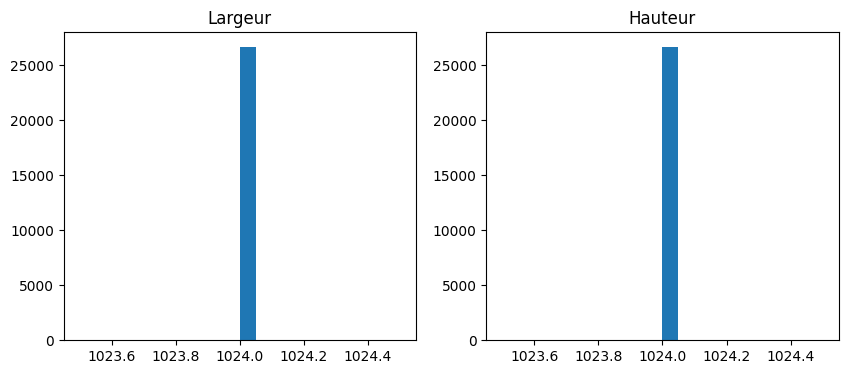

In [18]:
image_folder="/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images"

files=os.listdir(image_folder)

widths=[]
heights=[]

for f in tqdm(files):

    ds=pydicom.dcmread(os.path.join(image_folder,f))

    img=ds.pixel_array

    h,w=img.shape

    heights.append(h)
    widths.append(w)


resolution_df=pd.DataFrame({
    "Height":heights,
    "Width":widths
})

resolution_df.describe()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(widths,bins=20)
plt.title("Largeur")

plt.subplot(1,2,2)
plt.hist(heights,bins=20)
plt.title("Hauteur")

plt.show()

In [2]:
import os
import cv2
import pydicom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm


image_folder="/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images"

files=os.listdir(image_folder)


sharpness=[]


for f in tqdm(files):

    ds=pydicom.dcmread(os.path.join(image_folder,f))

    img=ds.pixel_array

    score=cv2.Laplacian(img,cv2.CV_64F).var()

    sharpness.append(score)

resolution_df["Sharpness"]=sharpness

plt.figure(figsize=(6,4))

plt.hist(sharpness,bins=40)

plt.title("

          de la netteté")
plt.xlabel("Variance du Laplacien")
plt.ylabel("Nombre d'images")

plt.show()

100%|██████████| 26684/26684 [10:37<00:00, 41.85it/s]


NameError: name 'resolution_df' is not defined

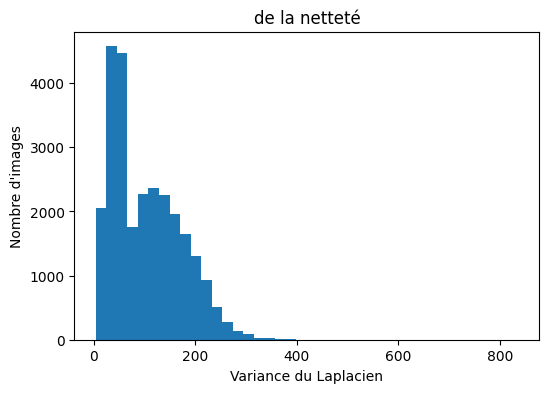

In [5]:

widths=[]
heights=[]

resolution_df=pd.DataFrame({
    "Height":heights,
    "Width":widths
})

resolution_df.describe()

resolution_df["Sharpness"]=sharpness

plt.figure(figsize=(6,4))

plt.hist(sharpness,bins=40)

plt.title("de la netteté")
plt.xlabel("Variance du Laplacien")
plt.ylabel("Nombre d'images")

plt.show()

100%|██████████| 26684/26684 [04:03<00:00, 109.61it/s]


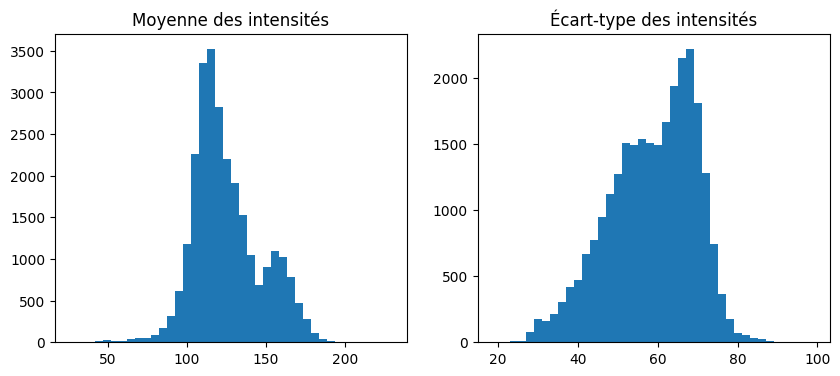

In [6]:
mean_pixels=[]
std_pixels=[]

for f in tqdm(files):

    ds=pydicom.dcmread(os.path.join(image_folder,f))

    img=ds.pixel_array.astype(np.float32)

    mean_pixels.append(img.mean())
    std_pixels.append(img.std())


resolution_df["MeanIntensity"]=mean_pixels
resolution_df["StdIntensity"]=std_pixels

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(mean_pixels,bins=40)
plt.title("Moyenne des intensités")

plt.subplot(1,2,2)
plt.hist(std_pixels,bins=40)
plt.title("Écart-type des intensités")

plt.show()